In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#dosya
df = pd.read_csv('/kaggle/input/datasets/carrie1/ecommerce-data/data.csv', encoding='ISO-8859-1')

# İlk 5 satırı ekrana getirelim
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
# 1. Veri setinin genel özetine ve eksik değerlerine bakalım
print('Orjinal Veri Boyutu:', df.shape)
print('\n---Eksik Değer Sayılar')
print(df.isnull().sum())

# 2. Müşteri bazlı analizler için CustomerID'si boş olan satırları çıkaralım
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 3. İptal/İade edilen işlermleri (C ile başlayan faturalar ve negatif adeetler) filtreleyelim
df_clean = df_clean[~df_clean['InvoiceNo'].str.startswith('C', na=False)]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 4. Tarih sütununu datatime tipine çevirelim
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 5. Toplam Harcama (TotalPrice) sütununu hesaplayalım
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("\nTemizlenmiş Veri Boyutu:", df_clean.shape)
df_clean.head()

Orjinal Veri Boyutu: (541909, 8)

---Eksik Değer Sayılar
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Temizlenmiş Veri Boyutu: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


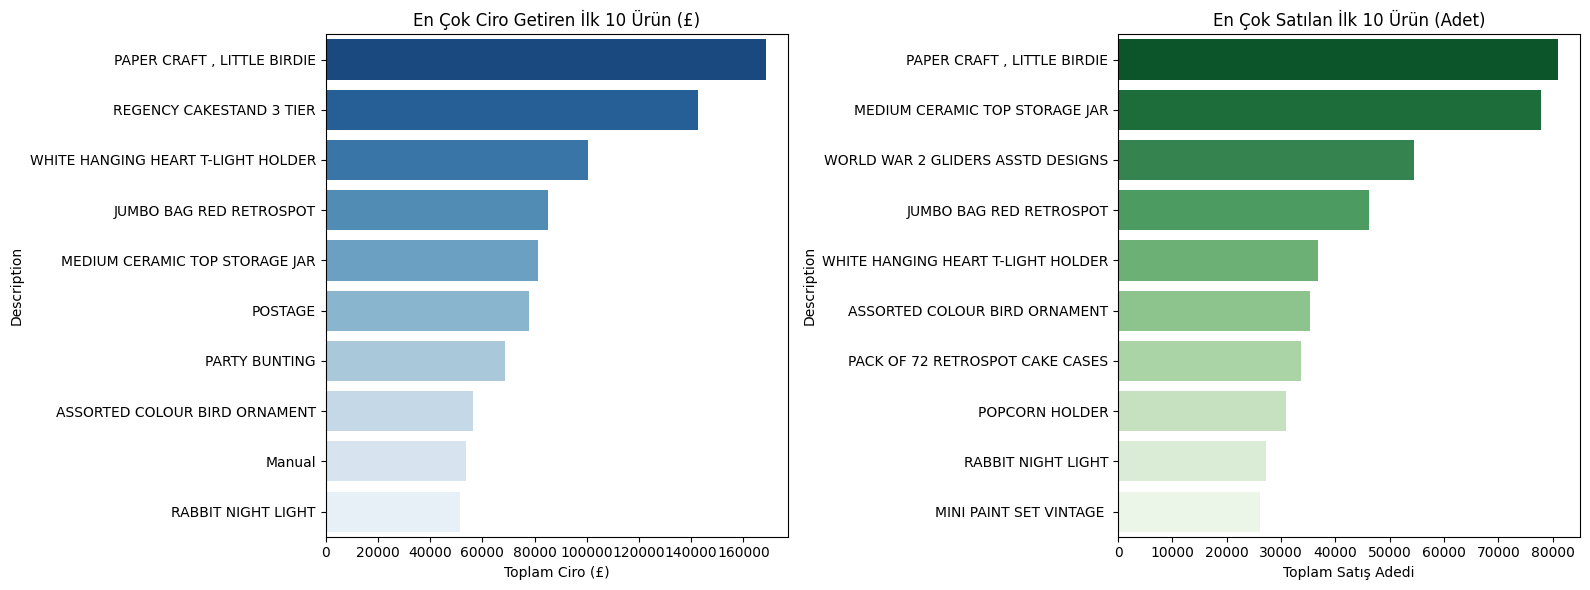

In [3]:
# 1. En çok ciro getiren ilk 10 ürünu bulalım
top_revenue_products = df_clean.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# 2. Adet bazından en çok satan ilk 10 ürünü bulalım
top_quantity_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# 3. Görselleştirme: Yan yana iki grafik çizdirelim
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol Grafik: Ciro Liderleri
sns.barplot(x=top_revenue_products.values, y=top_revenue_products.index, ax=axes[0], hue=top_revenue_products.index, legend=False, palette='Blues_r')
axes[0].set_title('En Çok Ciro Getiren İlk 10 Ürün (£)')
axes[0].set_xlabel('Toplam Ciro (£)')
# Sğ Grafik: Adet Liderleri
sns.barplot(x=top_quantity_products.values, y=top_quantity_products.index, ax=axes[1], hue=top_revenue_products.index, legend=False, palette='Greens_r')
axes[1].set_title('En Çok Satılan İlk 10 Ürün (Adet)')
axes[1].set_xlabel('Toplam Satış Adedi')

plt.tight_layout()
plt.show()


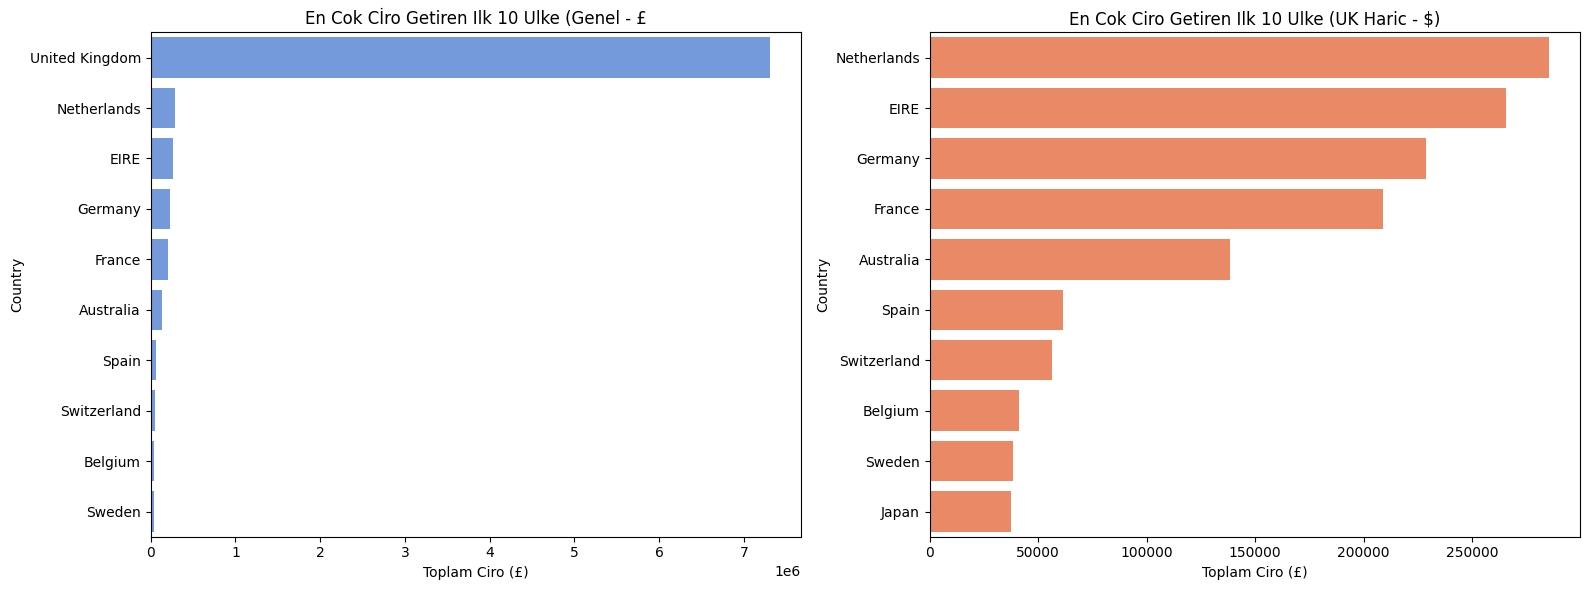

In [4]:
# 1. Genel: En çok ciro getiren ilk 10 ülke
top_countries_all = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# 2. Uluslararası: Birleşik Krallık (United Kingdom) HARİÇ ilk 10 ülke
top_countries_intl = df_clean[df_clean['Country'] != 'United Kingdom'].groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# 3. Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Sol Grafik: Genel Top 10
sns.barplot(x=top_countries_all.values, y=top_countries_all.index, ax=axes[0],color='cornflowerblue')
axes[0].set_title('En Cok Cİro Getiren Ilk 10 Ulke (Genel - £')
axes[0].set_xlabel('Toplam Ciro (£)')

# Sağ Grafik: UK Hariç Top 10 (Uluslararası Pazar)
sns.barplot(x=top_countries_intl.values, y=top_countries_intl.index, ax=axes[1], color='coral')
axes[1].set_title('En Cok Ciro Getiren Ilk 10 Ulke (UK Haric - $)')
axes[1].set_xlabel('Toplam Ciro (£)')

plt.tight_layout()
plt.show()

In [5]:
import datetime as dt

# 1. Analiz tarihini belirleyelim (Verideki son tarihten 1 gün sonrası)
analysis_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# 2. Her müşteri için Recency, Frequency ve Monetary değerlerini hesaplayalım
rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (analysis_date - date.max()).days),
    Frequency=('InvoiceDate','nunique'),
    Monetary=('TotalPrice' ,'sum'),
).reset_index()

# 3. Sonucu kontrol edelim
print("Toplam Müşteri Sayısı:", rfm.shape[0])
rfm.head()

Toplam Müşteri Sayısı: 4338


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [6]:
# 1. 1-5 arası Skorları Oluşturma (pd.qcut ile çeyreklere bölme)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# 2. RF Skorunu Metin OLarak Birleştirme (Örn: '55', '11')
rfm['RF_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)

# 3. Müşteri Segmentlerini Tanımlama (Regex Sözlüğü)
seg_map = {
    r'[1-2][1-2]' : 'Hibernating (Kış Uykusunda)',
    r'[1-2][3-4]': 'At Risk (Risk Altında)',
    r'[1-2]5': 'Cannot Lose Them (Kaybedilmemeli)',
    r'3[1-2]': 'About to Sleep (Uykuda / Kayıp Riski)',
    r'33': 'Need Attention (İlgi Gerektiren)',
    r'[3-4][4-5]': 'Loyal Customers (Sadık Müşteriler)',
    r'41': 'Promising (Umut Vaat Eden)',
    r'51': 'New Customers (Yeni Müşteriler)',
    r'[4-5][2-3]': 'Potential Loyalists (Potansiyel Sadık)',
    r'5[4-5]': 'Champions (Şampiyonlar)'
}

# 4. Segmentleri Haritalama
rfm['Segment'] = rfm['RF_Score'].replace(seg_map, regex=True)

# İlk 5 müşterinin yeni segmentini görelim
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RF_Score,Segment
0,12346,326,1,77183.60,1,1,5,11,Hibernating (Kış Uykusunda)
1,12347,2,7,4310.00,5,5,5,55,Champions (Şampiyonlar)
2,12348,75,4,1797.24,2,4,4,24,At Risk (Risk Altında)
3,12349,19,1,1757.55,4,1,4,41,Promising (Umut Vaat Eden)
4,12350,310,1,334.40,1,1,2,11,Hibernating (Kış Uykusunda)


/tmp/ipykernel_16/2787534019.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='magma')


<function matplotlib.pyplot.show(close=None, block=None)>

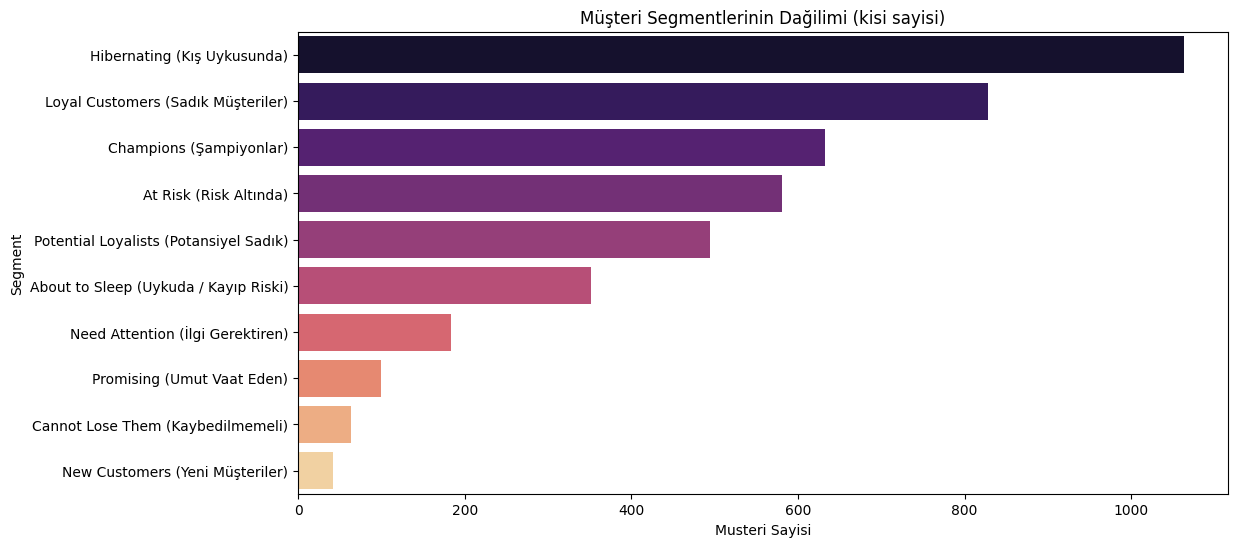

In [7]:
# Segment bazında müşteri sayıları
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='magma')
plt.title('Müşteri Segmentlerinin Dağilimi (kisi sayisi)')
plt.xlabel('Musteri Sayisi')
plt.show

In [8]:
# Segment bazında Recency, Frequency ve Monetary ortalamaları
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean','count']
}).round(1)

# Tabloyu daha okunaklı gösterelim
segment_summary.columns = ['Ortalama_Son_Gelis_Gunu','Ortalama_Siparis_Sayisi','Ortalama_Harcama', 'Musteri_Sayisi']
segment_summary.sort_values(by='Ortalama_Harcama', ascending=False)

,Ortalama_Son_Gelis_Gunu,Ortalama_Siparis_Sayisi,Ortalama_Harcama,Musteri_Sayisi
Segment,,,,
Champions (Şampiyonlar),5.9,12.3,6866.8,632
Loyal Customers (Sadık Müşteriler),33.5,6.4,2855.4,828
Cannot Lose Them (Kaybedilmemeli),131.5,8.3,2791.0,64
At Risk (Risk Altında),155.3,2.9,1071.7,581
Potential Loyalists (Potansiyel Sadık),17.1,2.0,1035.0,494
Need Attention (İlgi Gerektiren),52.9,2.3,885.9,183
Hibernating (Kış Uykusunda),218.0,1.1,487.9,1063
About to Sleep (Uykuda / Kayıp Riski),53.6,1.2,461.6,352
New Customers (Yeni Müşteriler),6.9,1.0,388.2,42
